#### Pytorch's computation graphs
- Pytorch performs its computations based on directed acyclic graph (DAG).
- The graph derives relationships between tensors from the input all the way down to the output.
- Pytorch builds this computation graph and uses it to compute the gradient accordingly.

<img src='images/computation_graph.png' width=500>

In [1]:
# create a graph
import torch

def compute_z(a, b, c):
    r1 = torch.sub(a, b)
    r2 = torch.mul(2, r1)
    z = torch.add(r2, c)
    return z

In [5]:
print("Scalar input: ",  compute_z(torch.tensor(1), torch.tensor(2), torch.tensor(3)))
print("Rank 1 input: ",  compute_z(torch.tensor([1]), torch.tensor([2]), torch.tensor([3])))
print("Rank 2 input: ",  compute_z(torch.tensor([[1]]), torch.tensor([[2]]), torch.tensor([[3]])))

Scalar input:  tensor(1)
Rank 1 input:  tensor([1])
Rank 2 input:  tensor([[1]])


##### Pytorch tensor objects store and update model parameters

In [12]:
a = torch.tensor(3., requires_grad=True)
print(a)
b = torch.tensor([1., 2., 3.], requires_grad=True)
print(b)

tensor(3., requires_grad=True)
tensor([1., 2., 3.], requires_grad=True)


In [15]:
w = torch.tensor([2.,3.,4.])
print(w.requires_grad)
w.requires_grad_()
print(w.requires_grad)

False
True


#### Glorot initialization (Xavier Glorot and Yoshua Bengio)
- In early development of DL, it was observed that random Uniform or random Normal weight initialization often result in poor model performance.
- Xavier Glorot and Yoshua Bengio proposed Xavier/Glorot initialization that can help to roughly balance the variance of the gradients across different layers, reducing too much attention at only one or a few layers while other layers lag behing.
- For Uniform Glorot/Xavier:

<img src="images/Glorot_uniform.png" width = 350>

- For Normal Glorot/Xavier:

<img src="images/Glorot_normal.png" width = 200>


In [18]:
# Glorot initialization (Xavier Glorot and Yoshua Bengio)
import torch.nn as nn 
torch.manual_seed(2)

w = torch.empty(2, 3)
nn.init.xavier_normal_(w)
print(w)

tensor([[ 0.2481, -0.1414, -0.2021],
        [-0.7621,  0.6606, -0.4005]])


#### Compute gradients via automatic differentiation
- Optimizing NN requires computing the gradients of the loss with respect to the NN weights.

In [21]:
# Compute the gradients of the loss w.r.t. trainable variables
# dL/dz * dz/dw = (-2*(y-z)) * (x) = 2 * (wx + b - y) * x
# dL/dz * dz/db = (-2*(y-z)) * (1) = 2 * (wx + b - y)

w = torch.tensor(1.0, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)
x = torch.tensor([1.4])
y = torch.tensor([2.1])
z = torch.add(torch.mul(w, x), b)
loss = (y-z).pow(2)
loss.backward()
print("Manual computation: ")
print("dl/dw: ", 2 * (w*x + b - y) * x)
print("dl/db: ", 2 * (w*x + b - y))

print("\nAutomatic computation")
print("dL/dw: ", w.grad)
print("dL/db: ", b.grad)

Manual computation: 
dl/dw:  tensor([-0.5600], grad_fn=<MulBackward0>)
dl/db:  tensor([-0.4000], grad_fn=<MulBackward0>)

Automatic computation
dL/dw:  tensor(-0.5600)
dL/db:  tensor(-0.4000)


##### Simplifying implementations of common architectures via torch.nn module

**With nn.Sequential**

In [23]:
model = nn.Sequential(
    nn.Linear(4, 16),
    nn.ReLU(),
    nn.Linear(16, 32),
    nn.ReLU()
)
model

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=32, bias=True)
  (3): ReLU()
)

In [26]:
print(model[0].weight)

Parameter containing:
tensor([[-0.0065, -0.4905,  0.2300, -0.0761],
        [-0.3666,  0.2938, -0.1270, -0.3402],
        [-0.0483, -0.2972,  0.0562,  0.1792],
        [ 0.0247,  0.0156, -0.0807,  0.3579],
        [ 0.4084,  0.0081, -0.4180,  0.2350],
        [ 0.1955,  0.2336, -0.1851,  0.2115],
        [ 0.3782,  0.3312, -0.3972,  0.0579],
        [-0.4221, -0.4224, -0.3378,  0.2031],
        [ 0.3331, -0.3680, -0.1007,  0.1601],
        [ 0.2610,  0.2248,  0.3384,  0.2873],
        [-0.3449,  0.1986,  0.0825, -0.4127],
        [ 0.3233,  0.3043, -0.3310, -0.0204],
        [ 0.2487,  0.1314,  0.4789, -0.3899],
        [-0.0515, -0.4901,  0.4987, -0.2696],
        [ 0.2515,  0.3041, -0.1435, -0.3049],
        [ 0.4122,  0.4954, -0.0611, -0.0595]], requires_grad=True)


In [27]:
# initialize the weight distribution for the first layer: Xavier uniform
nn.init.xavier_uniform_(model[0].weight)

# l1 penalty
l1_weight = 0.1
l1_penalty = l1_weight * model[2].weight.abs().sum()

##### Choosing a loss function

In [28]:
# loss_fn = nn.Sigmoid()
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

##### Solving an XOR classification problem

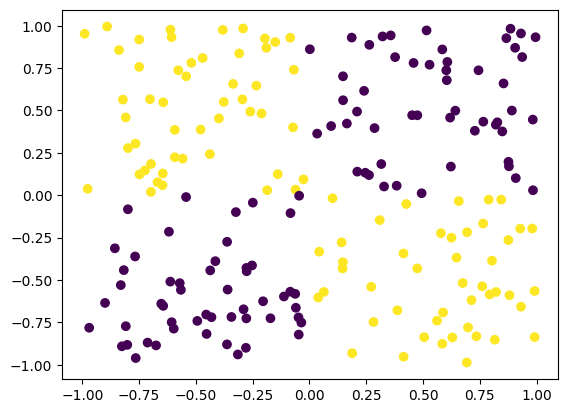

In [50]:
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(1)
X = np.random.uniform(low=-1, high=1, size=(200,2))
y = np.logical_xor(X[:, 0] > 0, X[:, 1] > 0).astype(int)
plt.scatter(X[:, 0], [X[:,1]], c=y)

In [60]:
n_train = 100
X_train = torch.tensor(X[:n_train], dtype=torch.float)
y_train = torch.tensor(y[:n_train], dtype=torch.float)
X_valid = torch.tensor(X[n_train:], dtype=torch.float)
y_valid = torch.tensor(y[n_train:], dtype=torch.float)

In [103]:
from torch.utils.data import Dataset, DataLoader, TensorDataset

train_ds = TensorDataset(X_train, y_train)
batch_size = 2
torch.manual_seed(2)
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

In [104]:
model = nn.Sequential(
    nn.Linear(2, 1),
    nn.Sigmoid(),
)
model

Sequential(
  (0): Linear(in_features=2, out_features=1, bias=True)
  (1): Sigmoid()
)

In [105]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001)

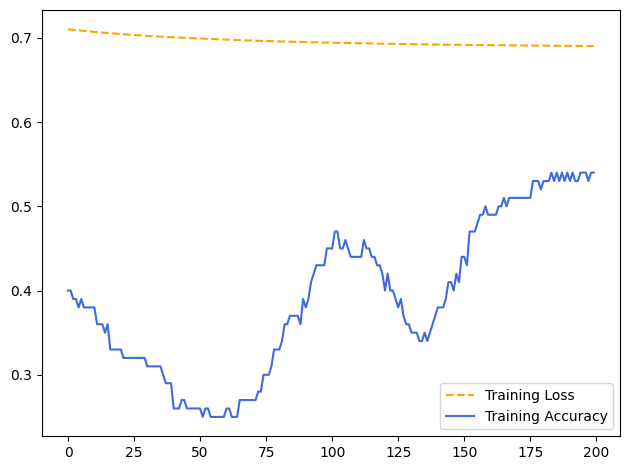

In [106]:
torch.manual_seed(1)
n_epochs = 200

def train(model, num_epochs, train_dl):
    accuracy_history = []
    loss_history = []
    for epoch in range(n_epochs):
        epoch_loss = 0
        epoch_accuracy = 0

        for x_batch, y_batch in train_dl:
            # feedforward
            y_pred = model.forward(x_batch)[:, 0]

            # compute loss
            loss = loss_fn(y_pred, y_batch)

            # backward to calculate grads
            loss.backward()

            # update parameters
            optimizer.step()
            optimizer.zero_grad() # reset the grads

            # track loss, acc
            epoch_loss += loss.item() * len(x_batch)
            is_correct = ((y_pred>=0.5).to(torch.long) == y_batch).sum()
            epoch_accuracy += is_correct.item()

        loss_history.append(epoch_loss/len(train_dl.dataset))
        accuracy_history.append(epoch_accuracy/len(train_dl.dataset))
    return loss_history, accuracy_history

loss_history, accuracy_history = train(model, n_epochs, train_dl)

plt.plot(loss_history, linestyle="--", color="orange", label="Training Loss")
plt.plot(accuracy_history, color="royalblue", label="Training Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


##### Adding complexity for model for XOR classification

In [115]:
complex_model = nn.Sequential(
    nn.Linear(2, 4),
    nn.ReLU(),
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Linear(4, 1),
    nn.Sigmoid()
)

complex_model

Sequential(
  (0): Linear(in_features=2, out_features=4, bias=True)
  (1): ReLU()
  (2): Linear(in_features=4, out_features=4, bias=True)
  (3): ReLU()
  (4): Linear(in_features=4, out_features=1, bias=True)
  (5): Sigmoid()
)

In [116]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(complex_model.parameters(), lr=0.015)

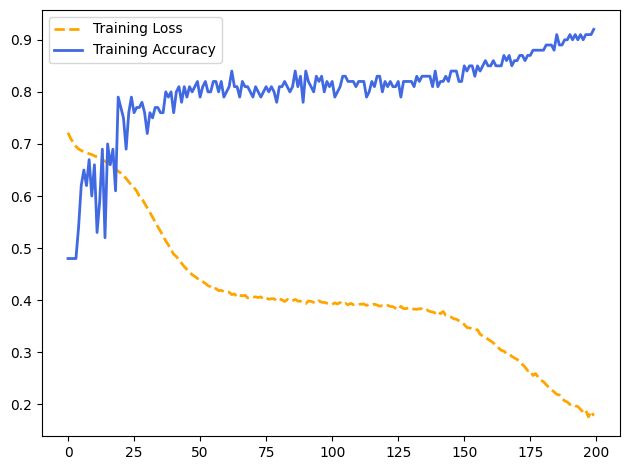

In [117]:
torch.manual_seed(1)
n_epochs = 200

loss_history, accuracy_history = train(complex_model, n_epochs, train_dl)

plt.plot(loss_history, linestyle="--", color="orange", label="Training Loss", lw=2)
plt.plot(accuracy_history, color="royalblue", label="Training Accuracy", lw=2)
plt.legend()
plt.tight_layout()
plt.show()


##### Making model building more flexible with nn.Module

In [118]:
class MyModule(nn.Module):
    def __init__(self):
        super().__init__()
        l1 = nn.Linear(2, 4)
        a1 = nn.ReLU()
        l2 = nn.Linear(4, 4)
        a2 = nn.ReLU()
        l3 = nn.Linear(4, 1)
        a3 = nn.ReLU()
        l = [l1, a1, l2, a2, l3, a3]
        self.module_list = nn.ModuleList(l)

    def forward(self, x):
        for f in self.module_list:
            x = f(x)
        return x

In [119]:
model = MyModule()
model

MyModule(
  (module_list): ModuleList(
    (0): Linear(in_features=2, out_features=4, bias=True)
    (1): ReLU()
    (2): Linear(in_features=4, out_features=4, bias=True)
    (3): ReLU()
    (4): Linear(in_features=4, out_features=1, bias=True)
    (5): ReLU()
  )
)

#### Writing custom layers in PyTorch

In [126]:
class NoisyLinear(nn.Module):
    def __init__(self, input_size, output_size, noise_stddev=0.1):
        super().__init__()
        w = torch.Tensor(input_size, output_size)
        self.w = nn.Parameter(w)
        nn.init.xavier_uniform_(self.w)
        b = torch.Tensor(output_size).fill_(0)
        self.b = nn.Parameter(b)
        self.noise_stddev = noise_stddev

    def forward(self, x, training=False):
        if training:
            noise = torch.normal(0.0, self.noise_stddev, x.shape)
            # print(noise)
            # print(torch.mm(noise, self.w))
            x_new = torch.add(x, noise)
        else:
            x_new = x
        return torch.add(torch.mm(x_new, self.w), self.b)

In [127]:
torch.manual_seed(1)
noisy_layer = NoisyLinear(4, 2)
x = torch.zeros((1, 4))
print(noisy_layer(x, training=True))
print(noisy_layer(x, training=True)) # different noise
print(noisy_layer(x, training=False))

tensor([[ 0.1154, -0.0598]], grad_fn=<AddBackward0>)
tensor([[ 0.0432, -0.0375]], grad_fn=<AddBackward0>)
tensor([[0., 0.]], grad_fn=<AddBackward0>)


In [128]:
class MyNoisyModule(nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = NoisyLinear(2, 4, 0.07)
        self.a1 = nn.ReLU()
        self.l2 = nn.Linear(4, 4)
        self.a2 = nn.ReLU()
        self.l3 = nn.Linear(4, 1)
        self.a3 = nn.Sigmoid()

    def forward(self, x, training=False):
        x = self.l1(x, training)
        x = self.a1(x)
        x = self.l2(x)
        x = self.a2(x)
        x = self.l3(x)
        x = self.a3(x)
        return x
    
    def predict(self, x):
        x = torch.tensor(x, dtype=torch.float32)
        pred = self.forward(x)[:, 0]
        return (pred>=0.5).float()

In [129]:
torch.manual_seed(1)
model = MyNoisyModule()
model

MyNoisyModule(
  (l1): NoisyLinear()
  (a1): ReLU()
  (l2): Linear(in_features=4, out_features=4, bias=True)
  (a2): ReLU()
  (l3): Linear(in_features=4, out_features=1, bias=True)
  (a3): Sigmoid()
)

In [ ]:
loss_fn = nn.BCELoss()
optimizer = torch.optim.SGD(params=model.parameters(), lr=0.01)

torch.manual_seed(1)

loss_history, accuracy_history = train(model, num_epochs=200, train_dl=train_dl)

plt.plot(loss_history, linestyle="--", color="orange", label="Training Loss", lw=2)
plt.plot(accuracy_history, color="royalblue", label="Training Accuracy", lw=2)
plt.legend()
plt.tight_layout()
plt.show()